# Astrometry: injection-vs-truth (foundation head vs classical, against known positions)

The label-based figures (Figs 7-8) measure agreement with VIS Gaussian centroids, which
could reflect emulation of the label convention rather than genuinely better positions.
This figure removes that ambiguity: sources of **known** position are injected into all ten
bands of held-out tiles, and each estimator's error is measured **against injected truth**.

Median truth error vs injected peak S/N, pooled over the Rubin optical bands (g r i z) at
matched injected difficulty: classical single-band centroid, foundation position head, and
the VIS anchor floor. The head is trained to reproduce VIS positions, so the VIS anchor error
is a hard floor it cannot beat; the result is that the head transfers VIS-level localization
to the photon-starved Rubin bands, where classical single-band centroids are ~2.5x worse.

Reads `io/_nb09_outputs/injection_truth_results_q1.json` (Q1 rerun, patch-disjoint held-out
subset). Saves `paper/figures/fig9_astrometry_injection.png`; running this notebook regenerates
the committed PNG.

saved paper/figures/fig9_astrometry_injection.png


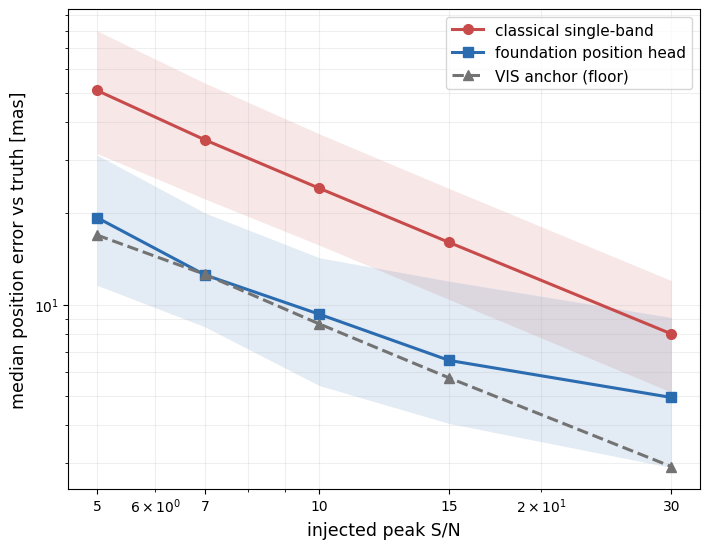

In [1]:
from pathlib import Path
import json, numpy as np, matplotlib.pyplot as plt
def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError
REPO=find_repo_root()
recs=json.load(open(REPO/'io/_nb09_outputs/injection_truth_results_q1.json'))['records']
SNRS=[5,7,10,15,30]
RUBOPT=['rubin_g','rubin_r','rubin_i','rubin_z']
def arr(field,filt):
    v=np.array([r[field] for r in recs if filt(r)],float)*1000  # arcsec -> mas
    return v[np.isfinite(v)]
def med_iqr(field,filt):
    v=arr(field,filt)
    if not len(v): return np.nan,np.nan,np.nan
    return np.median(v),np.percentile(v,25),np.percentile(v,75)

C_CLA='#c84b4b'; C_HEAD='#2b6cb0'; C_VIS='0.45'
series=[('err_band','classical single-band',C_CLA,'o','-'),
        ('err_head_prod','foundation position head',C_HEAD,'s','-'),
        ('err_vis','VIS anchor (floor)',C_VIS,'^','--')]
fig,ax=plt.subplots(figsize=(7.2,5.6))

# truth error vs INJECTED S/N, pooled over Rubin optical (matched difficulty)
for field,lab,col,mk,ls in series:
    m=[];lo=[];hi=[]
    for s in SNRS:
        a,b,c=med_iqr(field,lambda r,s=s: r['band'] in RUBOPT and r['snr']==s)
        m.append(a);lo.append(b);hi.append(c)
    m,lo,hi=map(np.array,(m,lo,hi))
    ax.plot(SNRS,m,ls,color=col,marker=mk,ms=7,lw=2.2,label=lab,zorder=3)
    if field!='err_vis': ax.fill_between(SNRS,lo,hi,color=col,alpha=0.13,lw=0,zorder=1)
ax.set_xscale('log');ax.set_yscale('log')
ax.set_xticks(SNRS);ax.set_xticklabels(SNRS)
ax.set_xlabel('injected peak S/N',fontsize=12.5)
ax.set_ylabel('median position error vs truth [mas]',fontsize=12.5)
ax.grid(True,which='both',alpha=0.2)
ax.legend(fontsize=11,frameon=True,loc='upper right')

plt.tight_layout()
OUT=REPO/'paper/figures/fig9_astrometry_injection.png'
fig.savefig(OUT,dpi=150,bbox_inches='tight'); print('saved',OUT.relative_to(REPO)); plt.show()